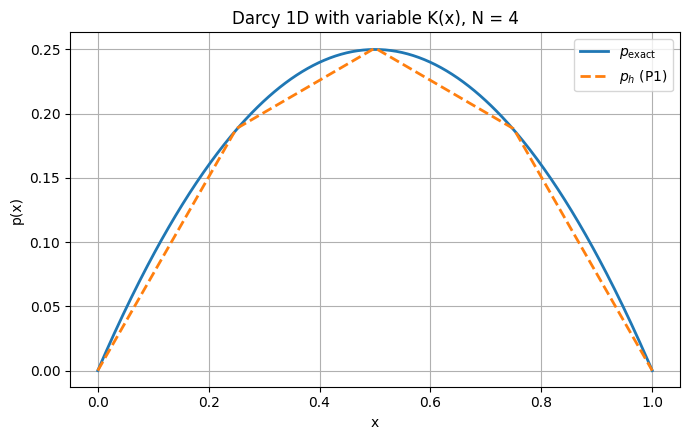

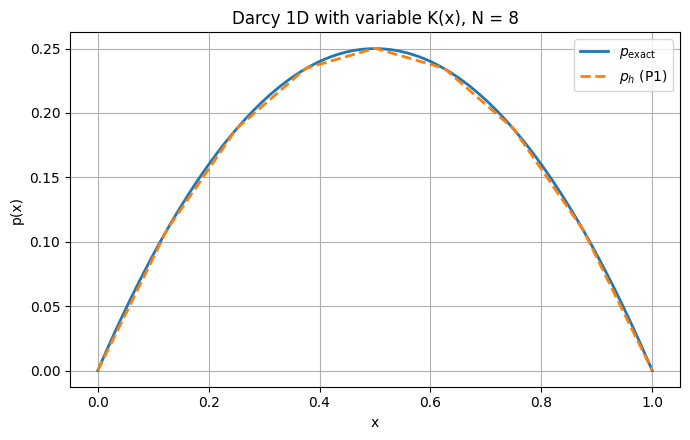

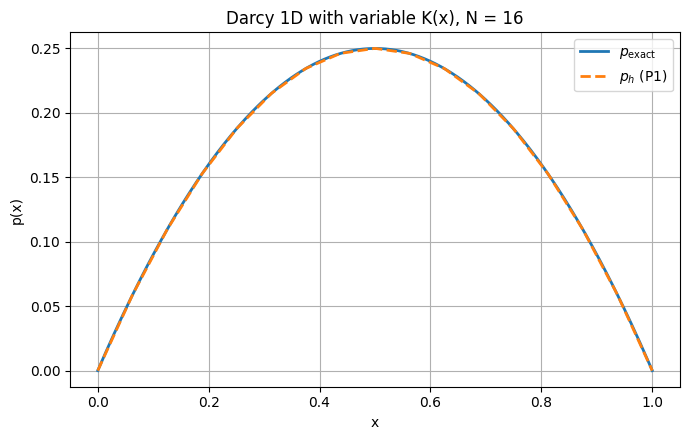

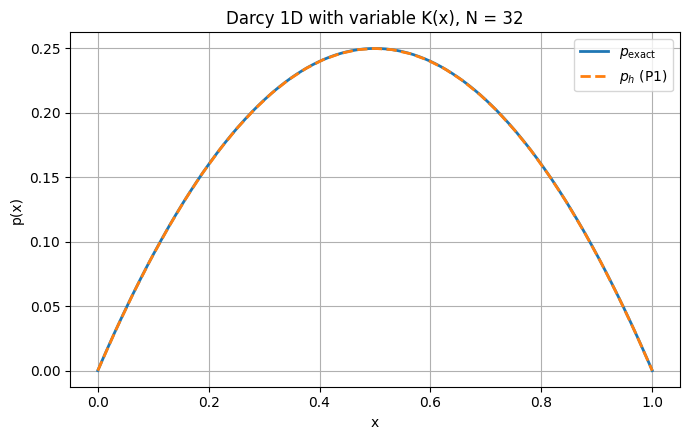

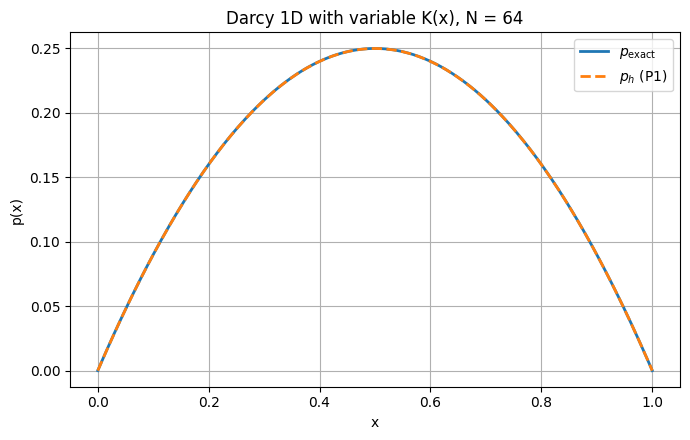

       N            h         ||e||_L2     rate(L2)           |e|_H1     rate(H1)
----------------------------------------------------------------------------------
       4 2.500000e-01   1.07905139e-02          ---   1.44358818e-01          ---
       8 1.250000e-01   2.69037767e-03     2.003883   7.21715613e-02     1.000157
      16 6.250000e-02   6.72143234e-04     2.000968   3.60847428e-02     1.000041
      32 3.125000e-02   1.68007641e-04     2.000242   1.80422399e-02     1.000011
      64 1.562500e-02   4.20001501e-05     2.000060   9.02110346e-03     1.000003


In [1]:
from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
from math import log
import matplotlib.pyplot as plt

from dolfinx import fem, mesh, geometry
from dolfinx.fem.petsc import LinearProblem
import ufl


def exact_p_array(x):
    return x[0] * (1.0 - x[0])


def solve_darcy_1d(ncells: int):
    """
    Solve
        -(K(x) p')' = f  on (0,1),
    with
        K(x) = 2 + x^2,
        p_exact(x) = x(1-x),
        f(x) = 4 - 2x - 6x^2.
    """
    comm = MPI.COMM_WORLD

    # Mesh
    domain = mesh.create_interval(comm, ncells, [0.0, 1.0])

    # P1 space
    V = fem.functionspace(domain, ("Lagrange", 1))

    # Trial and test functions
    p = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)

    x = ufl.SpatialCoordinate(domain)

    # Variable permeability and forcing
    K = 2.0 + x[0] ** 2
    f = 4.0 - 2.0 * x[0] + 6.0 * x[0] ** 2

    # K = 1
    # f= 2

    # Weak form: ∫ K p' v' dx = ∫ f v dx
    a = K * ufl.inner(ufl.grad(p), ufl.grad(v)) * ufl.dx
    L = f * v * ufl.dx

    # Boundary markers
    def left_boundary(x):
        return np.isclose(x[0], 0.0)

    def right_boundary(x):
        return np.isclose(x[0], 1.0)

    left_dofs = fem.locate_dofs_geometrical(V, left_boundary)
    right_dofs = fem.locate_dofs_geometrical(V, right_boundary)

    # Since p_exact(0)=0 and p_exact(1)=0
    p_left = fem.Constant(domain, PETSc.ScalarType(0.0))
    p_right = fem.Constant(domain, PETSc.ScalarType(0.0))

    bc_left = fem.dirichletbc(p_left, left_dofs, V)
    bc_right = fem.dirichletbc(p_right, right_dofs, V)
    bcs = [bc_left, bc_right]

    # Solve
    problem = LinearProblem(
        a,
        L,
        bcs=bcs,
        petsc_options_prefix=f"darcy1d_{ncells}_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
        },
    )

    ph = problem.solve()
    ph.name = "p_h"

    # Higher-order space for error computation
    W = fem.functionspace(domain, ("Lagrange", 4))

    p_exact_h = fem.Function(W)
    p_exact_h.interpolate(exact_p_array)

    ph_high = fem.Function(W)
    ph_high.interpolate(ph)

    # L2 error
    e_L2_form = fem.form((ph_high - p_exact_h) ** 2 * ufl.dx)
    e_L2 = np.sqrt(comm.allreduce(fem.assemble_scalar(e_L2_form), op=MPI.SUM))

    # H1 seminorm error
    e_H1_form = fem.form(
        ufl.inner(ufl.grad(ph_high - p_exact_h), ufl.grad(ph_high - p_exact_h)) * ufl.dx
    )
    e_H1 = np.sqrt(comm.allreduce(fem.assemble_scalar(e_H1_form), op=MPI.SUM))

    h = 1.0 / ncells
    return domain, ph, h, e_L2, e_H1


def convergence_rate(errors, hs):
    rates = [None]
    for i in range(1, len(errors)):
        r = log(errors[i - 1] / errors[i]) / log(hs[i - 1] / hs[i])
        rates.append(r)
    return rates


def plot_solution(domain, ph, ncells):
    """
    Plot p_h and p_exact on a fine set of points in [0,1].
    """
    comm = domain.comm
    rank = comm.rank

    # Fine plotting points
    x_plot = np.linspace(0.0, 1.0, 400, dtype=np.float64)
    points = np.zeros((len(x_plot), 3), dtype=np.float64)
    points[:, 0] = x_plot

    # Locate cells containing the points
    tree = geometry.bb_tree(domain, domain.topology.dim)
    cell_candidates = geometry.compute_collisions_points(tree, points)
    colliding_cells = geometry.compute_colliding_cells(domain, cell_candidates, points)

    points_on_proc = []
    cells = []
    x_local = []

    for i, point in enumerate(points):
        cell_list = colliding_cells.links(i)
        if len(cell_list) > 0:
            points_on_proc.append(point)
            cells.append(cell_list[0])
            x_local.append(x_plot[i])

    points_on_proc = np.array(points_on_proc, dtype=np.float64)
    x_local = np.array(x_local, dtype=np.float64)

    if len(points_on_proc) > 0:
        ph_vals_local = ph.eval(points_on_proc, cells).flatten()
        pexact_vals_local = x_local * (1.0 - x_local)
    else:
        ph_vals_local = np.array([], dtype=np.float64)
        pexact_vals_local = np.array([], dtype=np.float64)

    gathered_x = comm.gather(x_local, root=0)
    gathered_ph = comm.gather(ph_vals_local, root=0)
    gathered_pe = comm.gather(pexact_vals_local, root=0)

    if rank == 0:
        x_all = np.concatenate(gathered_x)
        ph_all = np.concatenate(gathered_ph)
        pe_all = np.concatenate(gathered_pe)

        idx = np.argsort(x_all)
        x_all = x_all[idx]
        ph_all = ph_all[idx]
        pe_all = pe_all[idx]

        plt.figure(figsize=(7, 4.5))
        plt.plot(x_all, pe_all, label=r"$p_{\mathrm{exact}}$", linewidth=2)
        plt.plot(x_all, ph_all, "--", label=r"$p_h$ (P1)", linewidth=2)
        plt.xlabel("x")
        plt.ylabel("p(x)")
        plt.title(f"Darcy 1D with variable K(x), N = {ncells}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    mesh_sizes = [4, 8, 16, 32, 64]

    hs = []
    L2_errors = []
    H1_errors = []

    for n in mesh_sizes:
        domain, ph, h, eL2, eH1 = solve_darcy_1d(n)

        hs.append(h)
        L2_errors.append(eL2)
        H1_errors.append(eH1)

        # Plot p_h and p_exact for each mesh
        plot_solution(domain, ph, n)

    L2_rates = convergence_rate(L2_errors, hs)
    H1_rates = convergence_rate(H1_errors, hs)

    if MPI.COMM_WORLD.rank == 0:
        print(f"{'N':>8} {'h':>12} {'||e||_L2':>16} {'rate(L2)':>12} {'|e|_H1':>16} {'rate(H1)':>12}")
        print("-" * 82)
        for i, n in enumerate(mesh_sizes):
            rL2 = "---" if L2_rates[i] is None else f"{L2_rates[i]:.6f}"
            rH1 = "---" if H1_rates[i] is None else f"{H1_rates[i]:.6f}"
            print(
                f"{n:8d} {hs[i]:12.6e} {L2_errors[i]:16.8e} {rL2:>12} "
                f"{H1_errors[i]:16.8e} {rH1:>12}"
            )


Max abs local conservation error = 0.18557389502997745


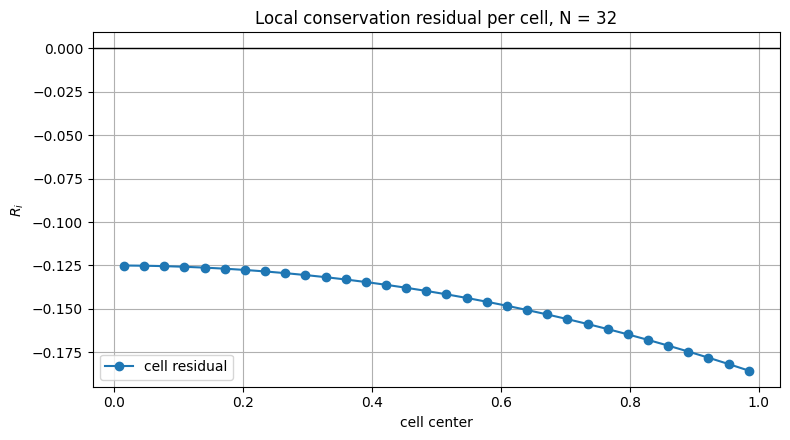

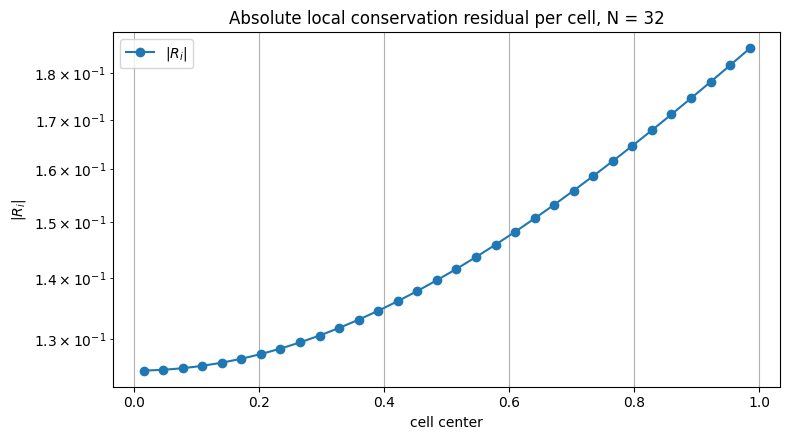

In [2]:
from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
import matplotlib.pyplot as plt

from dolfinx import fem, mesh
import ufl


def compute_local_conservation_error(domain, ph):
    """
    Compute cellwise local conservation residuals
        R_i = q_h(x_{i+1}^-) - q_h(x_i^+) - ∫_{K_i} f dx
    with q_h = -K(x) p_h'(x).

    Returns
    -------
    cell_centers : np.ndarray
    residuals    : np.ndarray
    abs_residuals: np.ndarray
    """
    V = ph.function_space
    comm = domain.comm
    tdim = domain.topology.dim

    # Ensure cell-vertex connectivity exists
    domain.topology.create_connectivity(tdim, 0)
    c_to_v = domain.topology.connectivity(tdim, 0)

    # P1 dof coordinates
    x_dofs = V.tabulate_dof_coordinates()[:, 0]
    u = ph.x.array

    num_cells_local = domain.topology.index_map(tdim).size_local

    cell_centers_local = np.zeros(num_cells_local, dtype=np.float64)
    residuals_local = np.zeros(num_cells_local, dtype=np.float64)

    for cell in range(num_cells_local):
        cell_dofs = V.dofmap.cell_dofs(cell)
        x_cell = x_dofs[cell_dofs]
        u_cell = u[cell_dofs]

        # Sort because local ordering is not something to assume blindly
        idx = np.argsort(x_cell)
        x0, x1 = x_cell[idx]
        p0, p1 = u_cell[idx]

        h = x1 - x0
        dpdx = (p1 - p0) / h   # constant on a P1 cell

        # Correct permeability and source
        def Kfun(x):
            return 2.0 + x**2
            # return 1

        # IMPORTANT: use corrected f
        def fint_exact(a, b):
            # ∫ (4 - 2x + 6x^2) dx from a to b
            return (4.0*b - b**2 + 2.0*b**3) - (4.0*a - a**2 + 2.0*a**3)
            # return 2*(b-a)

        # One-sided fluxes from inside this cell
        q_left = -Kfun(x0) * dpdx
        q_right = -Kfun(x1) * dpdx

        # Local conservation residual
        residual = q_right - q_left - fint_exact(x0, x1)

        cell_centers_local[cell] = 0.5 * (x0 + x1)
        residuals_local[cell] = residual

    # Gather to rank 0 for plotting
    gathered_centers = comm.gather(cell_centers_local, root=0)
    gathered_residuals = comm.gather(residuals_local, root=0)

    if comm.rank == 0:
        cell_centers = np.concatenate(gathered_centers)
        residuals = np.concatenate(gathered_residuals)

        idx = np.argsort(cell_centers)
        cell_centers = cell_centers[idx]
        residuals = residuals[idx]
        abs_residuals = np.abs(residuals)

        return cell_centers, residuals, abs_residuals

    return None, None, None


def plot_local_conservation_error(cell_centers, residuals, abs_residuals, N):
    plt.figure(figsize=(8, 4.5))
    plt.plot(cell_centers, residuals, "o-", label="cell residual")
    plt.axhline(0.0, color="k", linewidth=1)
    plt.xlabel("cell center")
    plt.ylabel(r"$R_i$")
    plt.title(f"Local conservation residual per cell, N = {N}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4.5))
    plt.semilogy(cell_centers, abs_residuals, "o-", label=r"$|R_i|$")
    plt.xlabel("cell center")
    plt.ylabel(r"$|R_i|$")
    plt.title(f"Absolute local conservation residual per cell, N = {N}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    N = 32

    # Make sure solve_darcy_1d uses the corrected source:
    # f = 4.0 - 2.0*x[0] + 6.0*x[0]**2
    domain, ph, h, eL2, eH1 = solve_darcy_1d(N)

    cell_centers, residuals, abs_residuals = compute_local_conservation_error(domain, ph)

    if MPI.COMM_WORLD.rank == 0:
        # print(f"{'cell center':>14} {'residual':>18} {'abs(residual)':>18}")
        # print("-" * 54)
        # for xc, r, ar in zip(cell_centers, residuals, abs_residuals):
        #     print(f"{xc:14.6e} {r:18.10e} {ar:18.10e}")

        print("\nMax abs local conservation error =", np.max(abs_residuals))
        plot_local_conservation_error(cell_centers, residuals, abs_residuals, N)

In [13]:
def reconstruct_flux_coeffs_1d(domain, ph):
    V = ph.function_space
    tdim = domain.topology.dim

    domain.topology.create_connectivity(tdim, 0)

    x_dofs = V.tabulate_dof_coordinates()[:, 0]
    u = ph.x.array

    num_cells = domain.topology.index_map(tdim).size_local

    x_left = np.zeros(num_cells)
    x_right = np.zeros(num_cells)

    a_vals = np.zeros(num_cells)  # slope
    b_vals = np.zeros(num_cells)  # intercept
    dpdx_vals = np.zeros(num_cells)

    def Kfun(x):
        return 2.0 + x**2

    def f_int(a, b):
        return (4.0*b - b**2 + 2.0*b**3) - (4.0*a - a**2 + 2.0*a**3)

    for cell in range(num_cells):
        cell_dofs = V.dofmap.cell_dofs(cell)
        x_cell = x_dofs[cell_dofs]
        u_cell = u[cell_dofs]

        idx = np.argsort(x_cell)
        x0, x1 = x_cell[idx]
        p0, p1 = u_cell[idx]

        h = x1 - x0
        dpdx = (p1 - p0) / h

        # reconstruction
        a = f_int(x0, x1) / h

        xc = 0.5 * (x0 + x1)
        rhs = -Kfun(xc) * dpdx * h
        integral_ax = a * (x1**2 - x0**2) / 2.0
        b = (rhs - integral_ax) / h

        x_left[cell] = x0
        x_right[cell] = x1
        a_vals[cell] = a
        b_vals[cell] = b
        dpdx_vals[cell] = dpdx

    return x_left, x_right, a_vals, b_vals, dpdx_vals

def plot_flux_comparison(domain, ph, N, nplot=400):
    comm = domain.comm
    rank = comm.rank

    x_left, x_right, a_vals, b_vals, dpdx_vals = reconstruct_flux_coeffs_1d(domain, ph)

    if rank != 0:
        return

    x_plot = np.linspace(0.0, 1.0, nplot)

    q_cg_plot = np.zeros_like(x_plot)
    q_rec_plot = np.zeros_like(x_plot)

    def Kfun(x):
        return 2.0 + x**2

    def q_exact(x):
        return -(2 + x**2) * (1 - 2*x)

    # evaluate piecewise
    for i, x in enumerate(x_plot):
        cell_id = np.searchsorted(x_right, x, side="right")
        if cell_id >= len(x_right):
            cell_id = len(x_right) - 1

        # CG flux (true)
        q_cg_plot[i] = -Kfun(x) * dpdx_vals[cell_id]

        # reconstructed flux (linear)
        q_rec_plot[i] = a_vals[cell_id] * x + b_vals[cell_id]

    q_exact_plot = q_exact(x_plot)

    plt.figure(figsize=(8, 4.5))
    plt.plot(x_plot, q_exact_plot, label=r"$q_{\mathrm{exact}}$", linewidth=2)
    plt.plot(x_plot, q_cg_plot, "--", label=r"$q_h=-Kp_h'$", linewidth=2)
    plt.plot(x_plot, q_rec_plot, "-.", label=r"$q_h^{rec}$", linewidth=2)

    plt.xlabel("x")
    plt.ylabel("flux")
    plt.title(f"Flux comparison (N = {N})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # errors
    err_cg = np.max(np.abs(q_cg_plot - q_exact_plot))
    err_rec = np.max(np.abs(q_rec_plot - q_exact_plot))

    print("Max error CG flux        =", err_cg)
    print("Max error reconstructed  =", err_rec)

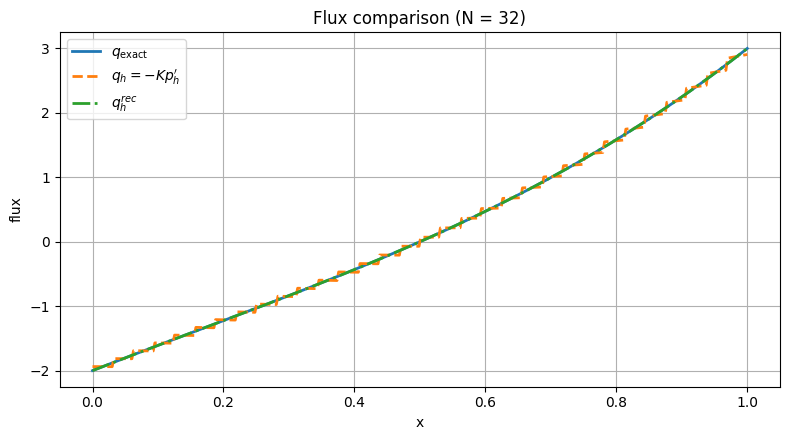

Max error CG flux        = 0.09357945289032132
Max error reconstructed  = 0.0010290304849611687


In [14]:
if __name__ == "__main__":
    N = 32
    domain, ph, h, eL2, eH1 = solve_darcy_1d(N)

    plot_flux_comparison(domain, ph, N)